In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving english_learning_dataset_2000.xlsx to english_learning_dataset_2000 (1).xlsx


In [5]:
import pandas as pd

file_name = "english_learning_dataset_2000.xlsx"

df = pd.read_excel(file_name)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 2000
Columns: 19


,Age,Current Language Level,Daily Study Time (Minutes),Weekly Practice Frequency,Vocabulary Mastery Confidence,Grammar & Sentence Structure Confidence,Listening Comprehension Confidence,Speaking Fluency & Oral Expression Confidence,Observed Learning Progress Track,Primary Learning Approach,Primary Role,Daily English Exposure,Years Learning English,English Learning Motivation,Reading Confidence,Writing Confidence,English Usage Frequency,Learning Goal,Preferred Practice Activity
0,20,Elementary,99,5,3,4,2,3,Fast Progress,Mixed/Combination,Student,Moderate,9,3,3,4,Several times a week,Personal Development,Online Courses
1,18,Elementary,109,6,4,3,3,4,Fast Progress,Visual Learning,Student,Very High,8,4,2,4,Multiple times a day,Communication,Language Learning Apps
2,20,Upper-Intermediate,122,6,4,4,5,5,Fast Progress,Reading/Writing,Student,Very High,8,5,4,2,Multiple times a day,Personal Development,Reading Books/Articles
3,22,Elementary,71,4,3,2,3,2,Moderate Progress,Mixed/Combination,Student,Moderate,8,2,3,3,Several times a week,Travel,Writing Practice
4,40,Elementary,51,3,3,3,3,1,Moderate Progress,Practice-Based,Self-employed,Moderate,11,2,3,3,Occasionally,Career/Work,Language Learning Apps


In [6]:
print("Total records:", len(df))
print("Total attributes:", len(df.columns))

print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(i, ":", col)

Total records: 2000
Total attributes: 19

Column names:
1 : Age
2 : Current Language Level
3 : Daily Study Time (Minutes)
4 : Weekly Practice Frequency
5 : Vocabulary Mastery Confidence
6 : Grammar & Sentence Structure Confidence
7 : Listening Comprehension Confidence
8 : Speaking Fluency & Oral Expression Confidence
9 : Observed Learning Progress Track
10 : Primary Learning Approach
11 : Primary Role
12 : Daily English Exposure
13 : Years Learning English
14 : English Learning Motivation
15 : Reading Confidence
16 : Writing Confidence
17 : English Usage Frequency
18 : Learning Goal
19 : Preferred Practice Activity


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nDataset size:")
print(df.shape)

Number of rows: 2000
Number of columns: 19

Dataset size:
(2000, 19)


In [8]:
size_summary = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Total Cells"],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.shape[0] * df.shape[1]
    ]
})

size_summary

,Metric,Value
0,Rows,2000
1,Columns,19
2,Total Cells,38000


In [9]:
print(df.columns.tolist())

['Age', 'Current Language Level', 'Daily Study Time (Minutes)', 'Weekly Practice Frequency', 'Vocabulary Mastery Confidence', 'Grammar & Sentence Structure Confidence', 'Listening Comprehension Confidence', 'Speaking Fluency & Oral Expression Confidence', 'Observed Learning Progress Track', 'Primary Learning Approach', 'Primary Role', 'Daily English Exposure', 'Years Learning English', 'English Learning Motivation', 'Reading Confidence', 'Writing Confidence', 'English Usage Frequency', 'Learning Goal', 'Preferred Practice Activity']


In [10]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Age', 'Current Language Level', 'Daily Study Time (Minutes)', 'Weekly Practice Frequency', 'Vocabulary Mastery Confidence', 'Grammar & Sentence Structure Confidence', 'Listening Comprehension Confidence', 'Speaking Fluency & Oral Expression Confidence', 'Observed Learning Progress Track', 'Primary Learning Approach', 'Primary Role', 'Daily English Exposure', 'Years Learning English', 'English Learning Motivation', 'Reading Confidence', 'Writing Confidence', 'English Usage Frequency', 'Learning Goal', 'Preferred Practice Activity']


In [11]:
print(df.dtypes)

Age                                               int64
Current Language Level                           object
Daily Study Time (Minutes)                        int64
Weekly Practice Frequency                         int64
Vocabulary Mastery Confidence                     int64
Grammar & Sentence Structure Confidence           int64
Listening Comprehension Confidence                int64
Speaking Fluency & Oral Expression Confidence     int64
Observed Learning Progress Track                 object
Primary Learning Approach                        object
Primary Role                                     object
Daily English Exposure                           object
Years Learning English                            int64
English Learning Motivation                       int64
Reading Confidence                                int64
Writing Confidence                                int64
English Usage Frequency                          object
Learning Goal                                   

In [12]:
dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": [df[col].nunique(dropna=True) for col in df.columns]
})

dtype_summary

,Column,Data Type,Unique Values
0,Age,int64,55
1,Current Language Level,object,5
2,Daily Study Time (Minutes),int64,127
3,Weekly Practice Frequency,int64,8
4,Vocabulary Mastery Confidence,int64,5
5,Grammar & Sentence Structure Confidence,int64,5
6,Listening Comprehension Confidence,int64,5
7,Speaking Fluency & Oral Expression Confidence,int64,5
8,Observed Learning Progress Track,object,3
9,Primary Learning Approach,object,5


In [14]:
numeric_columns = [
    "Age",
    "Daily Study Time (Minutes)",
    "Vocabulary Mastery Confidence",
    "Grammar & Sentence Structure Confidence",
    "Listening Comprehension Confidence",
    "Speaking Fluency & Oral Expression Confidence",
    "Years Learning English",
    "Reading Confidence",
    "Writing Confidence"
]

In [15]:
categorical_columns = [
    "Current Language Level",
    "Weekly Practice Frequency",
    "Observed Learning Progress Track",
    "Primary Learning Approach",
    "Primary Role",
    "Daily English Exposure",
    "English Learning Motivation",
    "English Usage Frequency",
    "Learning Goal",
    "Preferred Practice Activity"
]

In [16]:
for col in numeric_columns:
    print(f"{col}: {df[col].dtype}")

Age: int64
Daily Study Time (Minutes): int64
Vocabulary Mastery Confidence: int64
Grammar & Sentence Structure Confidence: int64
Listening Comprehension Confidence: int64
Speaking Fluency & Oral Expression Confidence: int64
Years Learning English: int64
Reading Confidence: int64
Writing Confidence: int64


In [17]:
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [18]:
null_counts = df.isnull().sum()

print(null_counts)

Age                                              0
Current Language Level                           0
Daily Study Time (Minutes)                       0
Weekly Practice Frequency                        0
Vocabulary Mastery Confidence                    0
Grammar & Sentence Structure Confidence          0
Listening Comprehension Confidence               0
Speaking Fluency & Oral Expression Confidence    0
Observed Learning Progress Track                 0
Primary Learning Approach                        0
Primary Role                                     0
Daily English Exposure                           0
Years Learning English                           0
English Learning Motivation                      0
Reading Confidence                               0
Writing Confidence                               0
English Usage Frequency                          0
Learning Goal                                    0
Preferred Practice Activity                      0
dtype: int64


In [19]:
null_percentage = (df.isnull().sum() / len(df)) * 100

null_summary = pd.DataFrame({
    "Column": df.columns,
    "Null Count": df.isnull().sum().values,
    "Null Percentage": null_percentage.round(2).values
})

null_summary

,Column,Null Count,Null Percentage
0,Age,0,0.0
1,Current Language Level,0,0.0
2,Daily Study Time (Minutes),0,0.0
3,Weekly Practice Frequency,0,0.0
4,Vocabulary Mastery Confidence,0,0.0
5,Grammar & Sentence Structure Confidence,0,0.0
6,Listening Comprehension Confidence,0,0.0
7,Speaking Fluency & Oral Expression Confidence,0,0.0
8,Observed Learning Progress Track,0,0.0
9,Primary Learning Approach,0,0.0


In [20]:
null_summary[null_summary["Null Count"] > 0]

,Column,Null Count,Null Percentage


In [21]:
df[df.isnull().any(axis=1)]

,Age,Current Language Level,Daily Study Time (Minutes),Weekly Practice Frequency,Vocabulary Mastery Confidence,Grammar & Sentence Structure Confidence,Listening Comprehension Confidence,Speaking Fluency & Oral Expression Confidence,Observed Learning Progress Track,Primary Learning Approach,Primary Role,Daily English Exposure,Years Learning English,English Learning Motivation,Reading Confidence,Writing Confidence,English Usage Frequency,Learning Goal,Preferred Practice Activity


In [22]:
for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [23]:
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [24]:
print("Total null values:", df.isnull().sum().sum())

Total null values: 0


In [25]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [26]:
df[df.duplicated()]

,Age,Current Language Level,Daily Study Time (Minutes),Weekly Practice Frequency,Vocabulary Mastery Confidence,Grammar & Sentence Structure Confidence,Listening Comprehension Confidence,Speaking Fluency & Oral Expression Confidence,Observed Learning Progress Track,Primary Learning Approach,Primary Role,Daily English Exposure,Years Learning English,English Learning Motivation,Reading Confidence,Writing Confidence,English Usage Frequency,Learning Goal,Preferred Practice Activity


In [27]:
df = df.drop_duplicates().reset_index(drop=True)

In [28]:
print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


In [29]:
separators = [",", ";", "|", "/", "&"]

for col in df.columns:
    for sep in separators:
        count = df[col].astype(str).str.contains(
            sep,
            regex=False,
            na=False
        ).sum()

        if count > 0:
            print(f"{col}: {count} cells contain '{sep}'")

Primary Learning Approach: 862 cells contain '/'
Primary Role: 361 cells contain '/'
Learning Goal: 729 cells contain '/'
Preferred Practice Activity: 665 cells contain '/'


In [30]:
for col in categorical_columns:
    mask = df[col].astype(str).str.contains(
        r"[,;|/&]",
        regex=True,
        na=False
    )

    if mask.sum() > 0:
        print("\nCOLUMN:", col)
        print(df.loc[mask, col].head(20).tolist())


COLUMN: Primary Learning Approach
['Mixed/Combination', 'Reading/Writing', 'Mixed/Combination', 'Mixed/Combination', 'Reading/Writing', 'Mixed/Combination', 'Reading/Writing', 'Reading/Writing', 'Mixed/Combination', 'Mixed/Combination', 'Mixed/Combination', 'Reading/Writing', 'Reading/Writing', 'Reading/Writing', 'Mixed/Combination', 'Mixed/Combination', 'Mixed/Combination', 'Mixed/Combination', 'Mixed/Combination', 'Mixed/Combination']

COLUMN: Primary Role
['Housewife/Homemaker', 'Housewife/Homemaker', 'Housewife/Homemaker', 'Housewife/Homemaker', 'Staff/Employee', 'Housewife/Homemaker', 'Staff/Employee', 'Staff/Employee', 'Housewife/Homemaker', 'Staff/Employee', 'Housewife/Homemaker', 'Staff/Employee', 'Staff/Employee', 'Staff/Employee', 'Staff/Employee', 'Housewife/Homemaker', 'Staff/Employee', 'Staff/Employee', 'Housewife/Homemaker', 'Staff/Employee']

COLUMN: Learning Goal
['Career/Work', 'Exams/Certifications', 'Career/Work', 'Career/Work', 'Career/Work', 'Exams/Certifications'

In [31]:
df["Preferred Practice Activity"] = (
    df["Preferred Practice Activity"]
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
)

In [32]:
for col in categorical_columns:
    print("\n" + "="*60)
    print(col)
    print(df[col].value_counts(dropna=False))


Current Language Level
Current Language Level
Elementary            704
Beginner              596
Intermediate          527
Upper-Intermediate    142
Advanced               31
Name: count, dtype: int64

Weekly Practice Frequency
Weekly Practice Frequency
5    586
4    522
6    373
3    272
7    148
2     81
1     16
0      2
Name: count, dtype: int64

Observed Learning Progress Track
Observed Learning Progress Track
Moderate Progress    867
Fast Progress        859
Slow Progress        274
Name: count, dtype: int64

Primary Learning Approach
Primary Learning Approach
Mixed/Combination    491
Practice-Based       416
Listening-Based      390
Reading/Writing      371
Visual Learning      332
Name: count, dtype: int64

Primary Role
Primary Role
Student                1340
Staff/Employee          230
Housewife/Homemaker     131
English Teacher         127
Self-employed            65
Retired Person           57
Other                    50
Name: count, dtype: int64

Daily English Exposure
D

In [33]:
for col in categorical_columns:
    df[col] = df[col].astype(str).str.strip()

In [34]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,26.0740,9.305311,16.0,20.0,23.0,28.0,72.0
Daily Study Time (Minutes),2000.0,86.9595,22.131104,17.0,72.0,87.0,102.0,159.0
Vocabulary Mastery Confidence,2000.0,3.1405,1.039375,1.0,2.0,3.0,4.0,5.0
Grammar & Sentence Structure Confidence,2000.0,2.8700,1.055773,1.0,2.0,3.0,4.0,5.0
Listening Comprehension Confidence,2000.0,3.0600,1.004940,1.0,2.0,3.0,4.0,5.0
Speaking Fluency & Oral Expression Confidence,2000.0,3.1495,1.043405,1.0,2.0,3.0,4.0,5.0
Years Learning English,2000.0,7.9940,3.401727,1.0,6.0,8.0,10.0,20.0
Reading Confidence,2000.0,3.0170,1.054641,1.0,2.0,3.0,4.0,5.0
Writing Confidence,2000.0,2.7190,1.040471,1.0,2.0,3.0,3.0,5.0


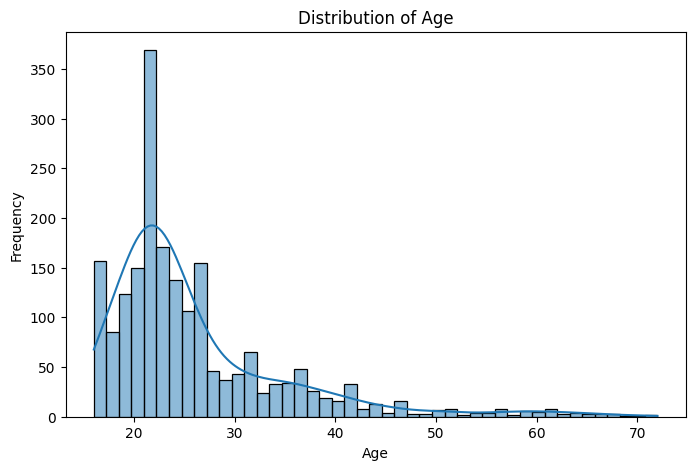

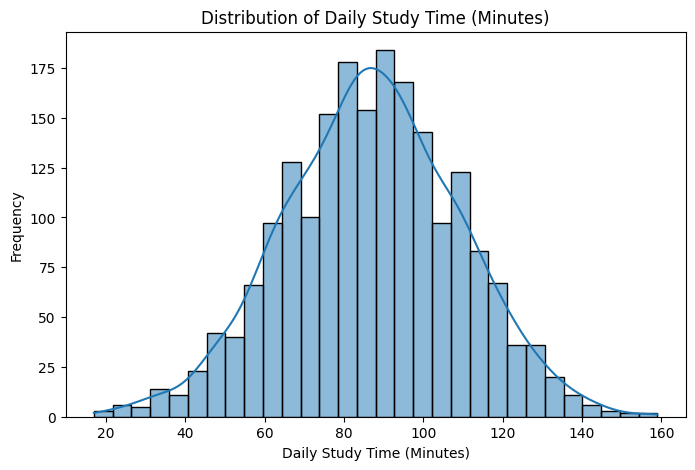

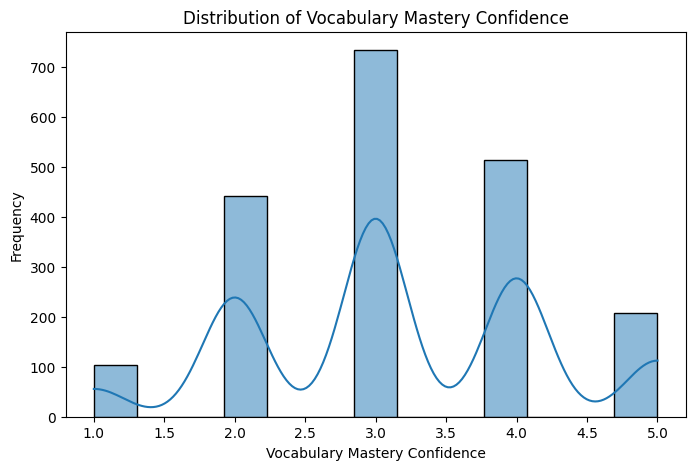

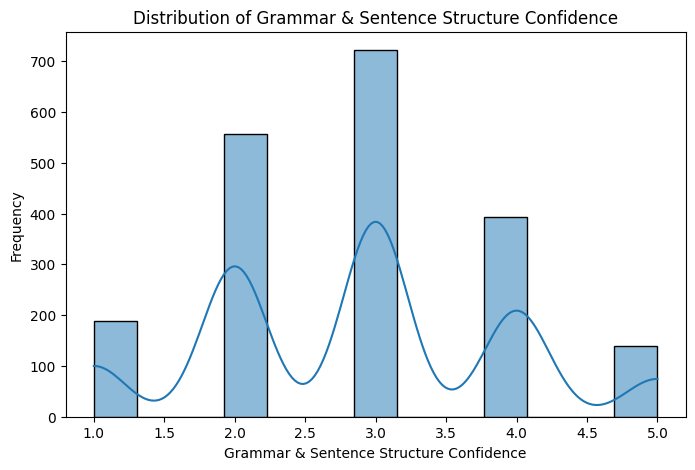

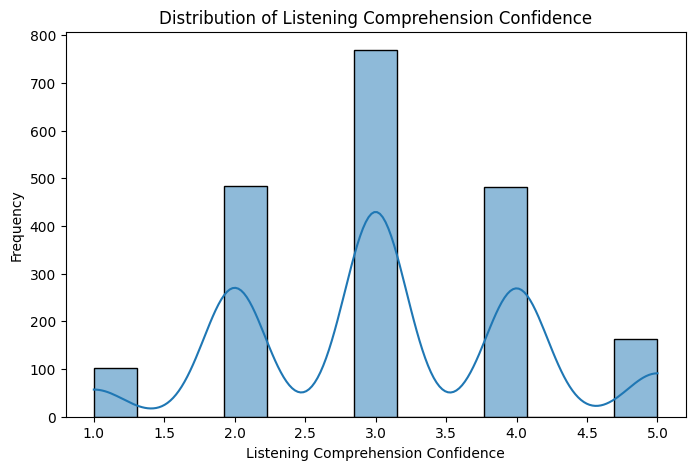

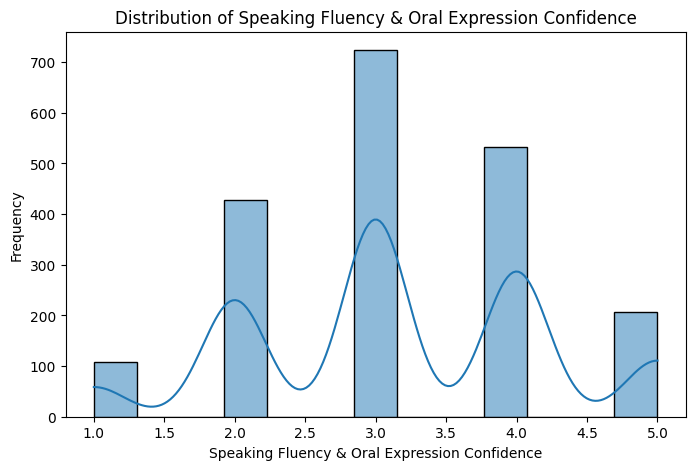

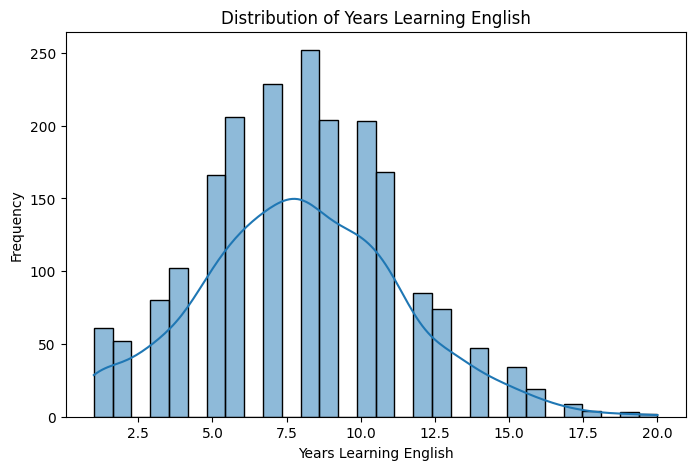

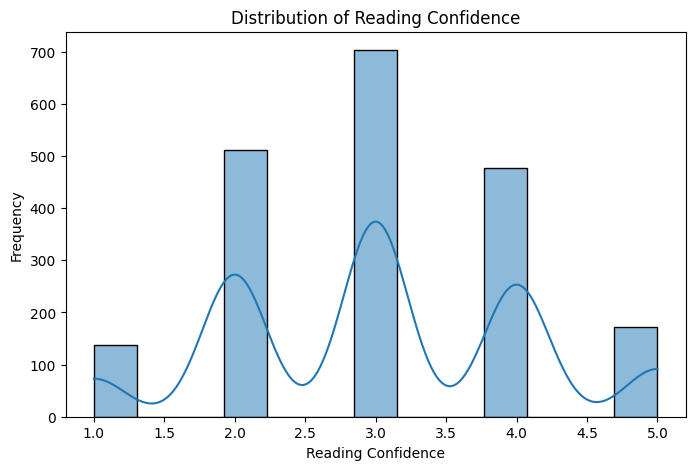

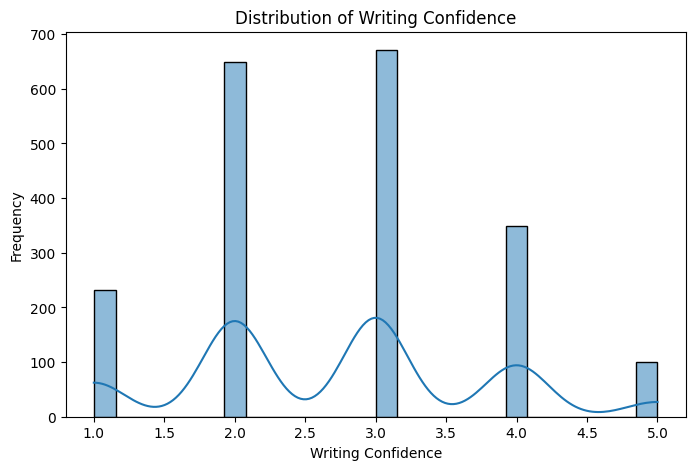

In [35]:
for col in numeric_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

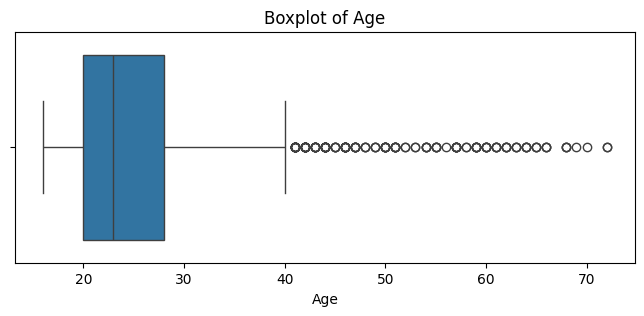

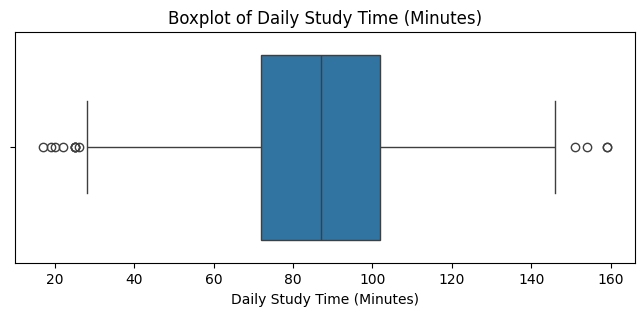

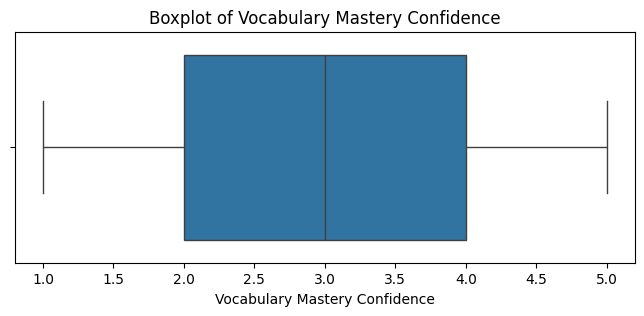

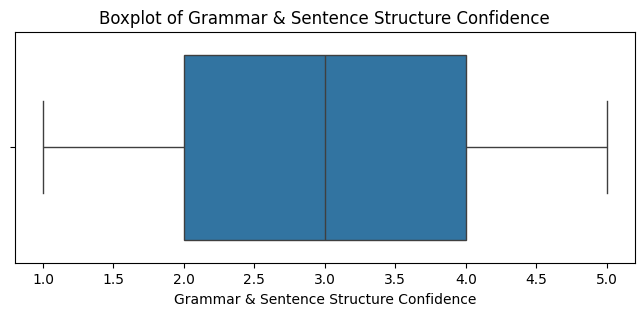

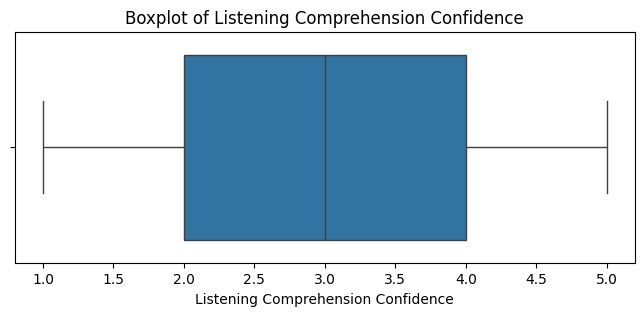

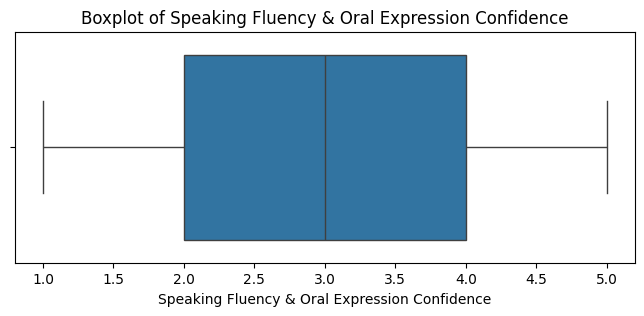

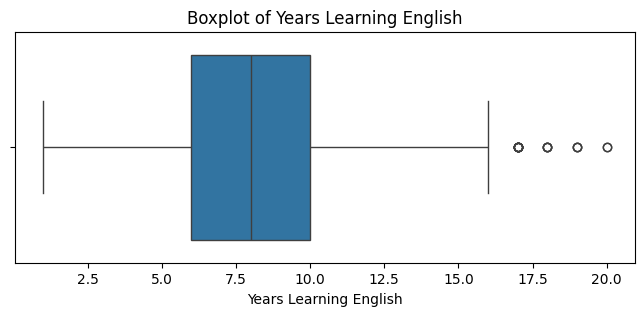

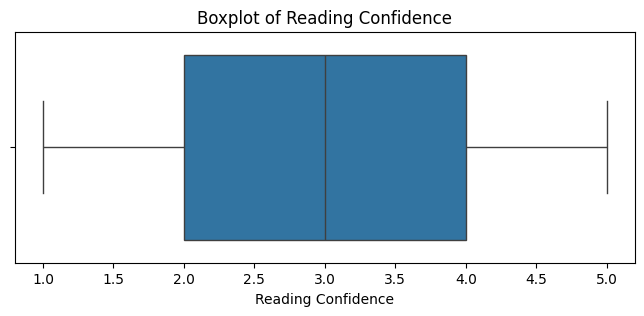

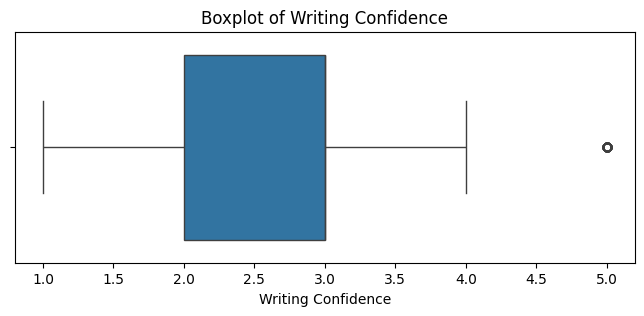

In [36]:
for col in numeric_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [37]:
outlier_summary = []

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Potential Outliers": count
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
0,Age,20.0,28.0,8.0,8.0,40.0,154
1,Daily Study Time (Minutes),72.0,102.0,30.0,27.0,147.0,13
2,Vocabulary Mastery Confidence,2.0,4.0,2.0,-1.0,7.0,0
3,Grammar & Sentence Structure Confidence,2.0,4.0,2.0,-1.0,7.0,0
4,Listening Comprehension Confidence,2.0,4.0,2.0,-1.0,7.0,0
5,Speaking Fluency & Oral Expression Confidence,2.0,4.0,2.0,-1.0,7.0,0
6,Years Learning English,6.0,10.0,4.0,0.0,16.0,18
7,Reading Confidence,2.0,4.0,2.0,-1.0,7.0,0
8,Writing Confidence,2.0,3.0,1.0,0.5,4.5,100


In [38]:
df["Age"].describe()

,Age
count,2000.000000
mean,26.074000
std,9.305311
min,16.000000
25%,20.000000
50%,23.000000
75%,28.000000
max,72.000000


In [39]:
df[(df["Age"] < 13) | (df["Age"] > 100)]

,Age,Current Language Level,Daily Study Time (Minutes),Weekly Practice Frequency,Vocabulary Mastery Confidence,Grammar & Sentence Structure Confidence,Listening Comprehension Confidence,Speaking Fluency & Oral Expression Confidence,Observed Learning Progress Track,Primary Learning Approach,Primary Role,Daily English Exposure,Years Learning English,English Learning Motivation,Reading Confidence,Writing Confidence,English Usage Frequency,Learning Goal,Preferred Practice Activity


In [40]:
df[df["Daily Study Time (Minutes)"] < 0]

,Age,Current Language Level,Daily Study Time (Minutes),Weekly Practice Frequency,Vocabulary Mastery Confidence,Grammar & Sentence Structure Confidence,Listening Comprehension Confidence,Speaking Fluency & Oral Expression Confidence,Observed Learning Progress Track,Primary Learning Approach,Primary Role,Daily English Exposure,Years Learning English,English Learning Motivation,Reading Confidence,Writing Confidence,English Usage Frequency,Learning Goal,Preferred Practice Activity


In [41]:
confidence_columns = [
    "Vocabulary Mastery Confidence",
    "Grammar & Sentence Structure Confidence",
    "Listening Comprehension Confidence",
    "Speaking Fluency & Oral Expression Confidence",
    "Reading Confidence",
    "Writing Confidence"
]

for col in confidence_columns:
    invalid = df[(df[col] < 1) | (df[col] > 5)]
    print(col, "invalid values:", len(invalid))

Vocabulary Mastery Confidence invalid values: 0
Grammar & Sentence Structure Confidence invalid values: 0
Listening Comprehension Confidence invalid values: 0
Speaking Fluency & Oral Expression Confidence invalid values: 0
Reading Confidence invalid values: 0
Writing Confidence invalid values: 0


In [42]:
df[df["Years Learning English"] < 0]

,Age,Current Language Level,Daily Study Time (Minutes),Weekly Practice Frequency,Vocabulary Mastery Confidence,Grammar & Sentence Structure Confidence,Listening Comprehension Confidence,Speaking Fluency & Oral Expression Confidence,Observed Learning Progress Track,Primary Learning Approach,Primary Role,Daily English Exposure,Years Learning English,English Learning Motivation,Reading Confidence,Writing Confidence,English Usage Frequency,Learning Goal,Preferred Practice Activity


In [43]:
for col in categorical_columns:
    print("\n", "="*60)
    print(col)
    print(df[col].value_counts())


Current Language Level
Current Language Level
Elementary            704
Beginner              596
Intermediate          527
Upper-Intermediate    142
Advanced               31
Name: count, dtype: int64

Weekly Practice Frequency
Weekly Practice Frequency
5    586
4    522
6    373
3    272
7    148
2     81
1     16
0      2
Name: count, dtype: int64

Observed Learning Progress Track
Observed Learning Progress Track
Moderate Progress    867
Fast Progress        859
Slow Progress        274
Name: count, dtype: int64

Primary Learning Approach
Primary Learning Approach
Mixed/Combination    491
Practice-Based       416
Listening-Based      390
Reading/Writing      371
Visual Learning      332
Name: count, dtype: int64

Primary Role
Primary Role
Student                1340
Staff/Employee          230
Housewife/Homemaker     131
English Teacher         127
Self-employed            65
Retired Person           57
Other                    50
Name: count, dtype: int64

Daily English Exposure
D

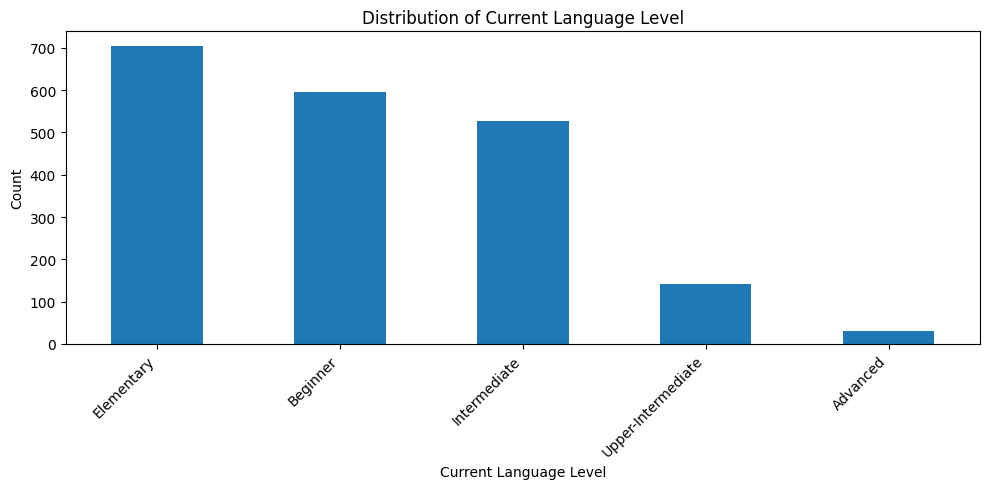

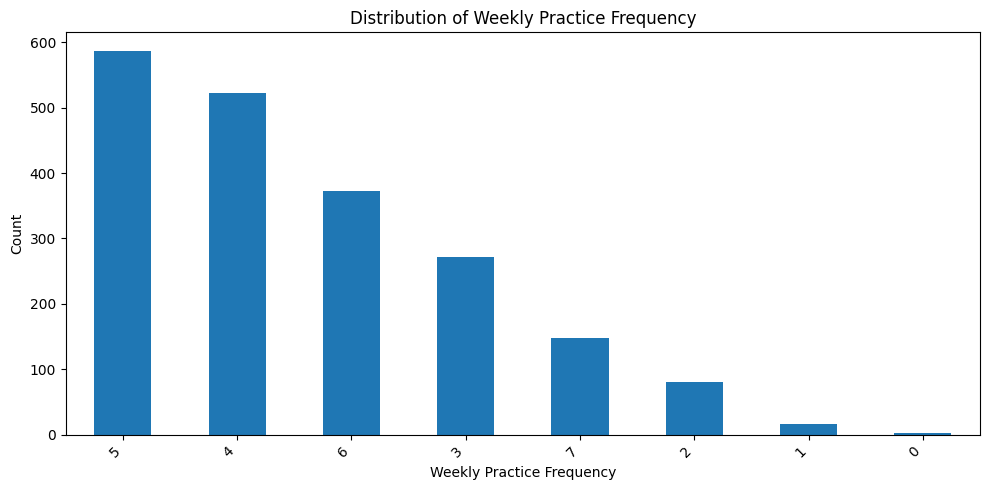

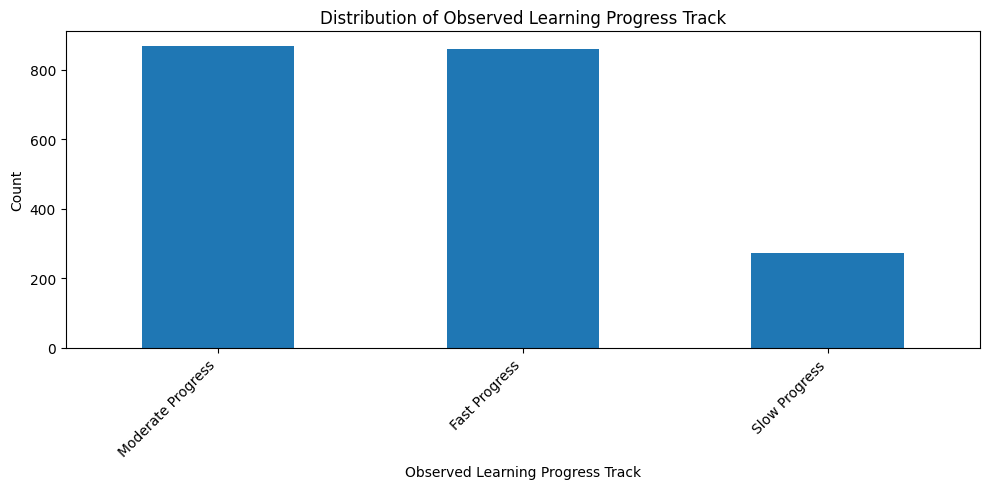

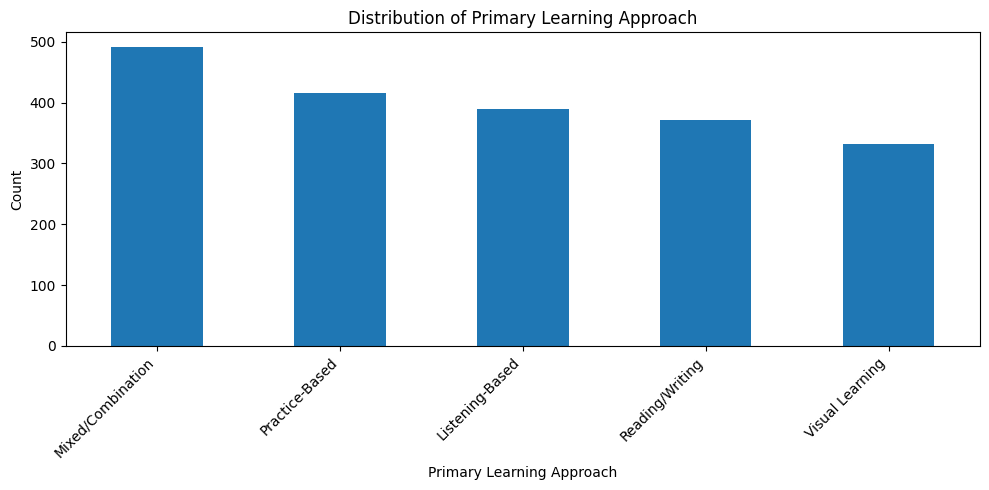

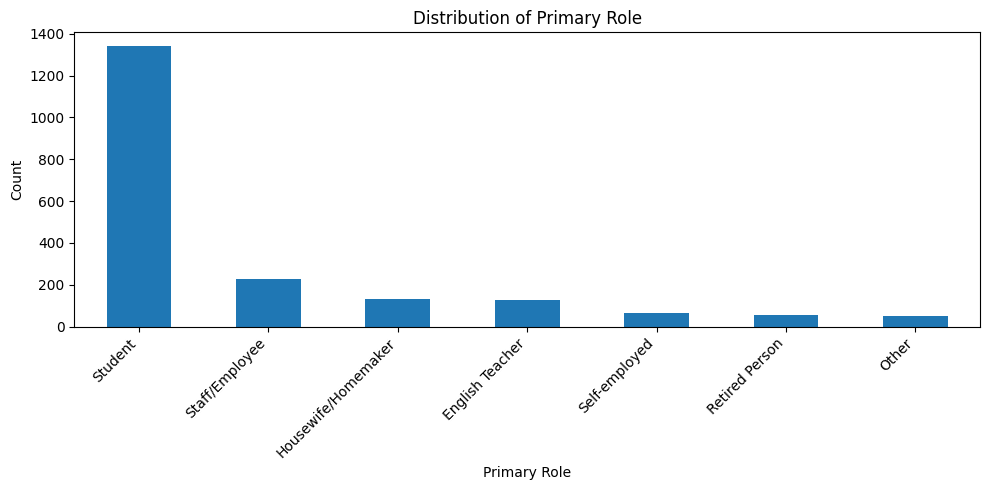

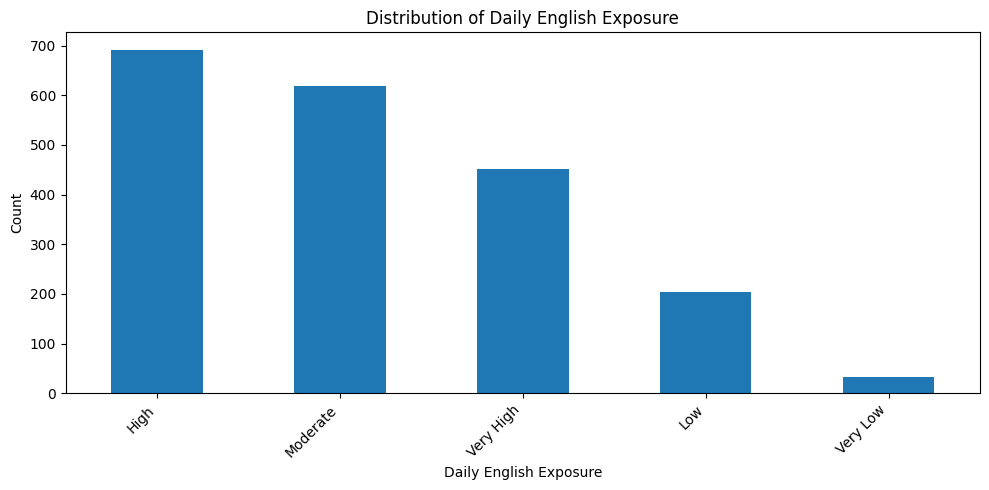

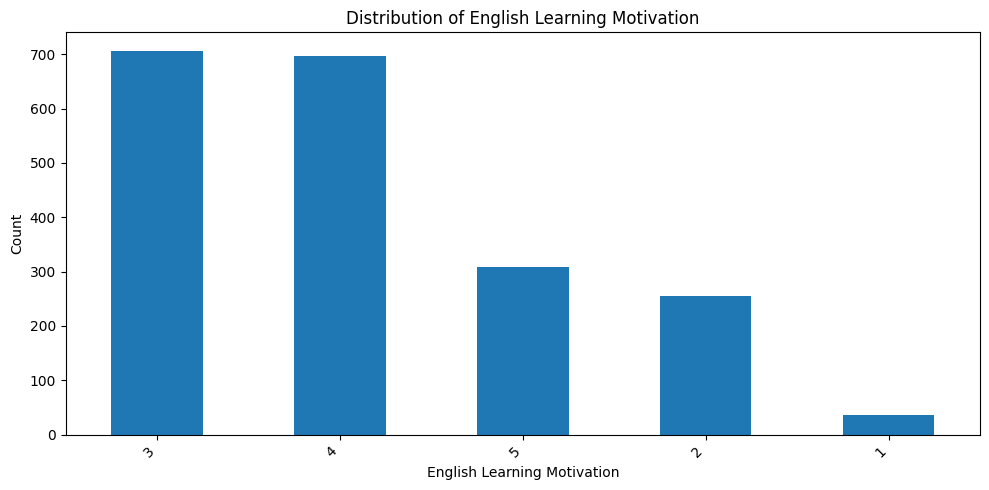

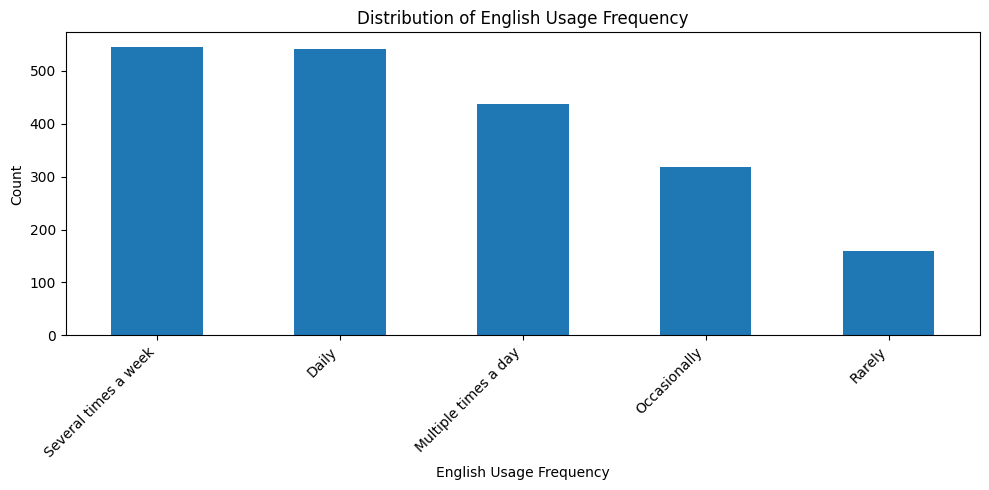

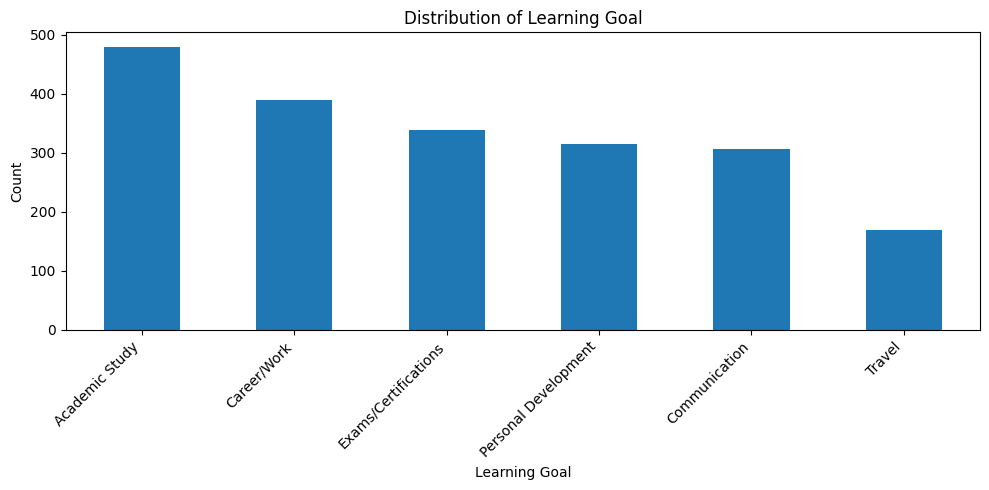

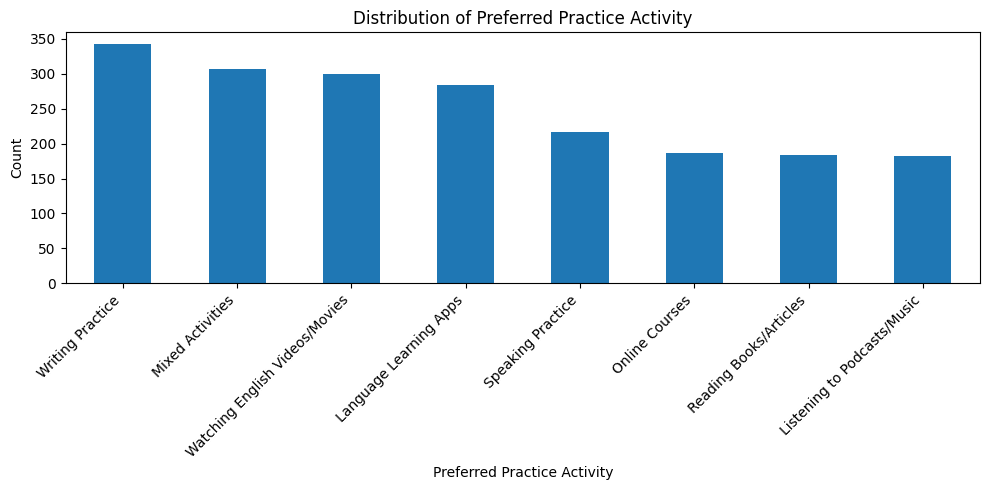

In [44]:
for col in categorical_columns:
    plt.figure(figsize=(10, 5))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [45]:
TARGET_COL = "Observed Learning Progress Track"

In [46]:
class_counts = df["Observed Learning Progress Track"].value_counts()

print(class_counts)

Observed Learning Progress Track
Moderate Progress    867
Fast Progress        859
Slow Progress        274
Name: count, dtype: int64


In [47]:
class_percentage = (
    df["Observed Learning Progress Track"]
    .value_counts(normalize=True)
    * 100
)

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentage.round(2)
})

class_distribution

,Count,Percentage
Observed Learning Progress Track,,
Moderate Progress,867,43.35
Fast Progress,859,42.95
Slow Progress,274,13.70


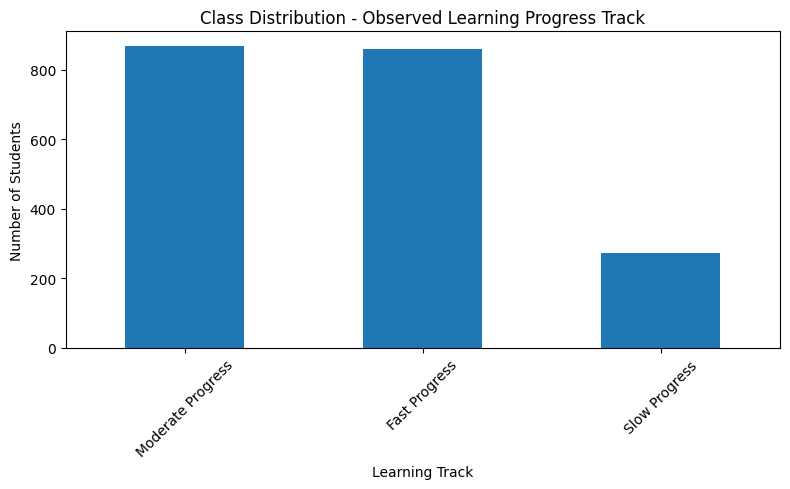

In [48]:
plt.figure(figsize=(8, 5))

df["Observed Learning Progress Track"].value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution - Observed Learning Progress Track")
plt.xlabel("Learning Track")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
print("Final shape:", df.shape)

print("\nNull values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Final shape: (2000, 19)

Null values:
0

Duplicate rows:
0

Data types:
Age                                               int64
Current Language Level                           object
Daily Study Time (Minutes)                        int64
Weekly Practice Frequency                        object
Vocabulary Mastery Confidence                     int64
Grammar & Sentence Structure Confidence           int64
Listening Comprehension Confidence                int64
Speaking Fluency & Oral Expression Confidence     int64
Observed Learning Progress Track                 object
Primary Learning Approach                        object
Primary Role                                     object
Daily English Exposure                           object
Years Learning English                            int64
English Learning Motivation                      object
Reading Confidence                                int64
Writing Confidence                                int64
English Usage Frequency         

In [50]:
df.head()

,Age,Current Language Level,Daily Study Time (Minutes),Weekly Practice Frequency,Vocabulary Mastery Confidence,Grammar & Sentence Structure Confidence,Listening Comprehension Confidence,Speaking Fluency & Oral Expression Confidence,Observed Learning Progress Track,Primary Learning Approach,Primary Role,Daily English Exposure,Years Learning English,English Learning Motivation,Reading Confidence,Writing Confidence,English Usage Frequency,Learning Goal,Preferred Practice Activity
0,20,Elementary,99,5,3,4,2,3,Fast Progress,Mixed/Combination,Student,Moderate,9,3,3,4,Several times a week,Personal Development,Online Courses
1,18,Elementary,109,6,4,3,3,4,Fast Progress,Visual Learning,Student,Very High,8,4,2,4,Multiple times a day,Communication,Language Learning Apps
2,20,Upper-Intermediate,122,6,4,4,5,5,Fast Progress,Reading/Writing,Student,Very High,8,5,4,2,Multiple times a day,Personal Development,Reading Books/Articles
3,22,Elementary,71,4,3,2,3,2,Moderate Progress,Mixed/Combination,Student,Moderate,8,2,3,3,Several times a week,Travel,Writing Practice
4,40,Elementary,51,3,3,3,3,1,Moderate Progress,Practice-Based,Self-employed,Moderate,11,2,3,3,Occasionally,Career/Work,Language Learning Apps


In [51]:
final_report = pd.DataFrame({
    "Metric": [
        "Number of Rows",
        "Number of Columns",
        "Total Null Values",
        "Duplicate Rows",
        "Numeric Columns",
        "Categorical Columns"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        len(numeric_columns),
        len(categorical_columns)
    ]
})

final_report

,Metric,Value
0,Number of Rows,2000
1,Number of Columns,19
2,Total Null Values,0
3,Duplicate Rows,0
4,Numeric Columns,9
5,Categorical Columns,10


In [52]:
clean_filename = "english_learning_clean.csv"

df.to_csv(clean_filename, index=False)

print(f"Clean dataset saved as: {clean_filename}")

Clean dataset saved as: english_learning_clean.csv


In [53]:
files.download(clean_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>